In [113]:
import pandas as pd
import copy
import matplotlib.pyplot as plt
import numpy as np

In [114]:
"""
Read in data for values and principles
"""
ess_df = pd.read_csv('ESS9-private/ESS9e03_2.csv')
country_col_name = 'cntry'

## Merge the schwartz value responses into one, so that you have a final dataframe 
# with the 21 items for the 10 schwartz values. - Universalism measured with 3

# Note: Hedonism *is* supposed to be part of self-enhancement and openness to change
higher_order_values_dict = {
    "Self-Transcendence" : ["Universalism", "Benevolence", ], 
    "Conservation" : ["Tradition", "Conformity", "Security"], 
    "Self-Enhancement" : ["Power", "Achievement", "Hedonism"], 
    "Openness to Change" : ["Hedonism", "Stimulation", "Self-Direction"]
}

value_dict = {
              "Universalism": ["ipeqopt", "ipudrst", "impenv"], 
              "Benevolence": ["iphlppl", "iplylfr"],

              "Tradition": ["ipmodst", "imptrad"], 
              "Conformity": ["ipfrule", "ipbhprp"],
              "Security": ["impsafe", "ipstrgv"],

              "Power": ["imprich", "iprspot"], 
              "Achievement": ["ipshabt", "ipsuces"], 
              "Hedonism": ["ipgdtim", "impfun"], 

              "Stimulation": ["impdiff", "ipadvnt"],
              "Self-Direction": ["ipcrtiv", "impfree"],  
              }

principle_dict = {
    "income_dist" : "sofrdst",  # Society fair when income and wealth is equally distributed
    "work_earnings" : "sofrwrk", # Society fair when hard-working people earn more than others
    "care_of_poor" : "sofrpr" # Society fair when takes care of poor and in need, regardless of what give back 
}

ess_df = ess_df

# Find the list of all countries
ess_country_list = ess_df[country_col_name].unique()

# Iterate through each country and find their values
country_values = {}
for country in ess_country_list:
    country_df = ess_df.loc[ess_df[country_col_name] == country]
    temp_values = []
    # Iterate through and find all values, summing for each 
    #   question. temp_values will be in same order as values_dict
    # Then find the central preference by finding mean of each of these.
    for key, values in value_dict.items():
        temp_questions = []
        for question in values:
            # Invert all the items such that higher scores represent greater importance (inverted = 1 = worst, 6 = best)
            country_df[question] = country_df[question].values[::-1]
            # Find mean score for every col
            mean_score = country_df[question].sum() / len(country_df)
            # temp_questions contains the mean score of every question for that specific value, in thesame order as the list for the values_dict
            temp_questions.append(copy.copy(mean_score))
        # temp_values contains the list of mean scores for each question for that value, in the same order as the values_dict
        temp_values.append(copy.copy(temp_questions))
    # country_values contains the list of mean scores for every question for the country
    country_values[country] = copy.copy(temp_values)

# Subtract the mean score across all values (for a single country) from a value's raw score. This produces centrered values.
# country_values = dict({country_name: [[value1_q1, value1_q2], [value2_q1, value2_q2], [..]]})
for country, values in country_values.items():
    # Find the sum of all the values in the nested list (values), and compute the mean
    total = 0
    num_of_questions = 0
    for value_list in values:
        num_of_questions += len(value_list)
        total += sum(value_list)
    mean = total / num_of_questions

    # For every value in the nested list: values, subtract the mean from it, to find a centered value
    for value_list in values:
        for value in value_list:
            value_list[value_list.index(value)] = value - mean

print(country_values["AT"])

print("Country names: ", country_values.keys())


/var/folders/0n/fc0bjxts017cp6mfdzq9xxy40000gn/T/ipykernel_15506/2365267097.py:4: DtypeWarning: Columns (189,191,197,199) have mixed types. Specify dtype option on import or set low_memory=False.
  ess_df = pd.read_csv('ESS9-private/ESS9e03_2.csv')
/var/folders/0n/fc0bjxts017cp6mfdzq9xxy40000gn/T/ipykernel_15506/2365267097.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  country_df[question] = country_df[question].values[::-1]


[[np.float64(-0.522589988376303), np.float64(-0.2764915490005526), np.float64(-0.8031021932582558)], [np.float64(-0.5205891880561748), np.float64(-0.9695687798929098)], [np.float64(0.37456887516911497), np.float64(-0.1024219211494124)], [np.float64(0.6354732369138127), np.float64(-0.2152670592046344)], [np.float64(-0.5838144781722217), np.float64(-0.4985803845347663)], [np.float64(1.5002191352731566), np.float64(0.057642104460831955)], [np.float64(0.19129556584538543), np.float64(0.36976695440080753)], [np.float64(-0.05920463423464639), np.float64(0.16688580193982316)], [np.float64(0.5694468263495871), np.float64(1.3813715962575506)], [np.float64(-0.07521103679567087), np.float64(-0.6198288839345265)]]
Country names:  dict_keys(['AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'HR', 'HU', 'IE', 'IS', 'IT', 'LT', 'LV', 'ME', 'NL', 'NO', 'PL', 'PT', 'RS', 'SE', 'SI', 'SK'])


/var/folders/0n/fc0bjxts017cp6mfdzq9xxy40000gn/T/ipykernel_15506/3077804376.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


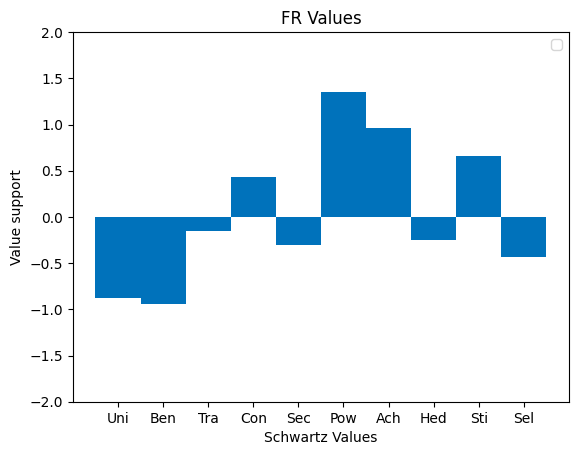

[-0.88161573 -0.94637527 -0.14761905  0.43397299 -0.30383795  1.35362473
  0.96307747 -0.25259417  0.65536603 -0.43319119]
[np.float64(-0.9139954986969911), np.float64(-0.005828002842928133), np.float64(0.6880360104240703), np.float64(-0.010139777303956357)]
[np.float64(-0.550095238095238), np.float64(-0.3528730158730156), np.float64(0.5844603174603176), np.float64(0.5436825396825399)]
[np.float64(-0.4415734235406368), np.float64(-0.35219880301847534), np.float64(0.451140601960274), np.float64(0.5363257871454591)]
[np.float64(-0.6914667971936693), np.float64(-0.3808125305922663), np.float64(0.6483113069016153), np.float64(0.5221080110947953)]
[np.float64(-0.8293686803214936), np.float64(-0.06084175957134234), np.float64(0.7008793535563043), np.float64(0.1553560625702184)]


Text(0.5, 1.0, 'DE')

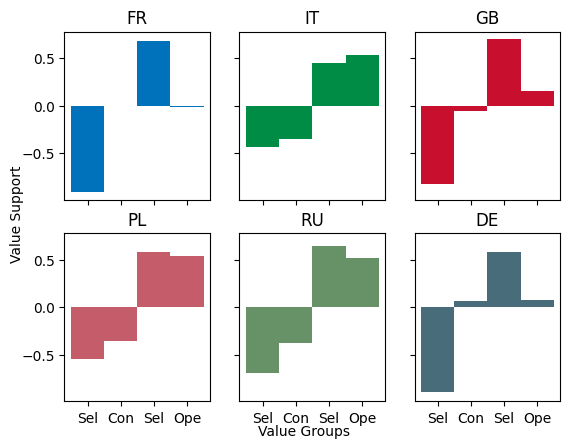

In [132]:
"""
Do some plots for the Schwartz Values (and higher order values)
"""

def make_a_plot(colour, country_code, data, attributes, attribute_cut_point):
    for attribute in attributes:
        attributes[attributes.index(attribute)] = attribute[:attribute_cut_point]        
    
    length = len(data)
    x_labels = attributes

    # Set plot parameters
    fig, ax = plt.subplots()
    width = 1
    x = np.arange(length)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel('Schwartz Values')
    title = country_code + " Values"
    ax.set_title(title)
    ax.set_ylabel('Value support')
    ax.legend()
    ax.bar(x, data, width, color=colour)

    plt.ylim(-2, 2) # Set y-axis  
    plt.show()

# Make a simple histogram for a country showing their Schwartz value distribution
fr_data = np.array([
    np.mean(v) for v in country_values["FR"]
])
pl_data = np.array([
    np.mean(v) for v in country_values["PL"]
])
it_data = np.array([
    np.mean(v) for v in country_values["IT"]
])
ru_data = np.array([
    np.mean(v) for v in country_values["RS"]
])
gb_data = np.array([
    np.mean(v) for v in country_values["GB"]
])
de_data = np.array([
    np.mean(v) for v in country_values["DE"]
])
attributes = list(value_dict.keys())

make_a_plot('#0072bb', "FR", fr_data, attributes, 3)
#make_a_plot('#C55C6A', "PL", pl_data)
#make_a_plot('#008C45', "IT", it_data)

print(fr_data)
#higher_order_values_dict = {
#    "Self-Transcendence" : ["Universalism", "Benevolence", ], 
#    "Conservation" : ["Tradition", "Conformity", "Security"], 
#    "Self-Enhancement" : ["Power", "Achievement", "Hedonism"], 
#    "Openness to Change" : ["Hedonism", "Stimulation", "Self-Direction"]
#}
higher_order_index_dict = {
    "Self-Transcendence" : [0, 1], 
    "Conservation" : [2, 3, 4], 
    "Self-Enhancement" : [5, 6, 7], 
    "Openness to Change" : [7, 8, 9]
}

attributes = list(higher_order_values_dict.keys())

def convert_to_higher_order(data):
    grouped_data = []
    for _, values in higher_order_index_dict.items():
        # Find mean for each total item
        mean_temp = 0
        total = 0
        for value in values:
            total += data[value]
        mean_temp = total / len(values)
        grouped_data.append(copy.copy(mean_temp))
    return grouped_data


fr_grouped_data = convert_to_higher_order(fr_data)
print(fr_grouped_data)
#make_a_plot('#0072bb', "FR", fr_grouped_data, attributes, 6)

pl_grouped_data = convert_to_higher_order(pl_data)
print(pl_grouped_data)
#make_a_plot('#C55C6A', "PL", pl_grouped_data, attributes, 6)

it_grouped_data = convert_to_higher_order(it_data)
print(it_grouped_data)
#make_a_plot('#008C45', "IT", it_grouped_data, attributes, 6)

ru_grouped_data = convert_to_higher_order(ru_data)
print(ru_grouped_data)
#make_a_plot('#679267', "RU", ru_grouped_data, attributes, 6)

gb_grouped_data = convert_to_higher_order(gb_data)
print(gb_grouped_data)
#make_a_plot('#C8102E', "GB", gb_grouped_data, attributes, 6)
de_grouped_data = convert_to_higher_order(de_data)


# Make multiple plots:
width = 1
for attribute in attributes:
    attributes[attributes.index(attribute)] = attribute[:3]        

length = len(fr_grouped_data)   # This will be the same for every "grouped_data"
x_labels = attributes
x = np.arange(length)

fig, axs = plt.subplots(2, 3, sharex=True, sharey=True,)

# Labels
fig.text(0.5, 0.04, 'Value Groups', ha='center')
fig.text(0.04, 0.5, 'Value Support', va='center', rotation='vertical')

axs[0, 0].bar(x, fr_grouped_data, width, color="#0072bb")
# Below seems to set common xticks and xticklabels
axs[0, 0].set_title("FR")
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(x_labels)

axs[1, 0].bar(x, pl_grouped_data, width, color="#C55C6A")
axs[1, 0].set_title("PL")

axs[0, 1].bar(x, it_grouped_data, width, color="#008C45")
axs[0, 1].set_title("IT")

axs[1, 1].bar(x, ru_grouped_data, width, color="#679267")
axs[1, 1].set_title("RU")

axs[0, 2].bar(x, gb_grouped_data, width, color="#C8102E")
axs[0, 2].set_title("GB")

axs[1, 2].bar(x, de_grouped_data, width, color="#486C7A")
axs[1, 2].set_title("DE")

[array([0.54061625]), array([-0.38535414]), array([-0.1552621])]
Country names:  dict_keys(['AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'HR', 'HU', 'IE', 'IS', 'IT', 'LT', 'LV', 'ME', 'NL', 'NO', 'PL', 'PT', 'RS', 'SE', 'SI', 'SK'])
Attributes:  ['inc', 'wor', 'car']


/var/folders/0n/fc0bjxts017cp6mfdzq9xxy40000gn/T/ipykernel_15506/3552928969.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  country_df[question] = country_df[question].values[::-1]


Text(0.5, 1.0, 'DE')

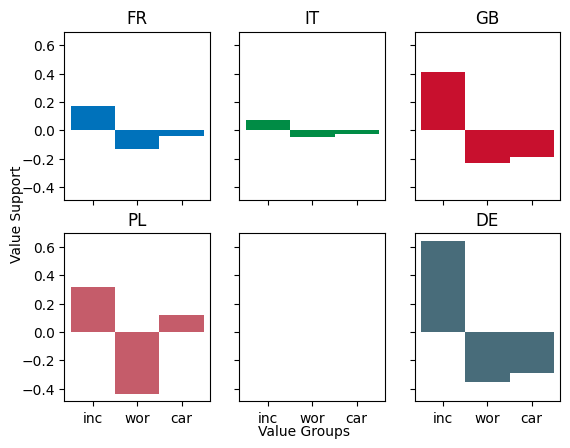

In [ ]:
# Read in principles and do analysis on similarities between Schwartz and principles
country_principles = {}
for country in ess_country_list:
    country_df = ess_df.loc[ess_df[country_col_name] == country]
    temp_values = []
    # Iterate through and find all values, summing for each 
    #   question. temp_values will be in same order as values_dict
    # Then find the central preference by finding mean of each of these.
    for key, question in principle_dict.items():
        temp_questions = []
        # Invert all the items such that higher scores represent greater importance (inverted = 1 = worst, 6 = best)
        country_df[question] = country_df[question].values[::-1]
        # Find mean score for every col
        mean_score = country_df[question].sum() / len(country_df)
        # temp_questions contains the mean score of every question for that specific value, in thesame order as the list for the values_dict
        temp_questions.append(copy.copy(mean_score))
        temp_values.append(copy.copy(temp_questions))
    # country_values contains the list of mean scores for every question for the country
    country_principles[country] = copy.copy(temp_values)

# Subtract the mean score across all values (for a single country) from a value's raw score. This produces centrered values.
# country_values = dict({country_name: [[value1_q1, value1_q2], [value2_q1, value2_q2], [..]]})
for country, values in country_principles.items():
    # Find the sum of all the values in the nested list (values), and compute the mean
    num_of_questions = len(values)
    total = np.sum(values)
    mean = total / num_of_questions

    # For every value in the nested list: values, subtract the mean from it, to find a centered value
    for value in values:
            values[values.index(value)] = value - mean

print(country_principles["AT"])

print("Country names: ", country_principles.keys())


## Make a simple histogram for a country showing their Schwartz value distribution
fr_principles = np.array([
    np.mean(v) for v in country_principles["FR"]
])
pl_principles = np.array([
    np.mean(v) for v in country_principles["PL"]
])
it_principles = np.array([
    np.mean(v) for v in country_principles["IT"]
])
de_principles = np.array([
    np.mean(v) for v in country_principles["DE"]
])
gb_principles = np.array([
    np.mean(v) for v in country_principles["GB"]
])
#ru_principles = np.array([
#    np.mean(v) for v in country_principles["RU"]
#])


# Make multiple plots:

## TODO: Add a mean point to the plot

width = 1
attributes = list(principle_dict.keys())
for attribute in attributes:
    attributes[attributes.index(attribute)] = attribute[:3]        
print("Attributes: ", attributes)
length = len(fr_principles)   # This will be the same for every "grouped_data"
x_labels = attributes
x = np.arange(length)

fig, axs = plt.subplots(2, 3, sharex=True, sharey=True,)

# Labels
fig.text(0.5, 0.04, 'Value Groups', ha='center')
fig.text(0.04, 0.5, 'Value Support', va='center', rotation='vertical')

axs[0, 0].bar(x, fr_principles, width, color="#0072bb")
# Below seems to set common xticks and xticklabels
axs[0, 0].set_title("FR")
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(x_labels)

axs[1, 0].bar(x, pl_principles, width, color="#C55C6A")
axs[1, 0].set_title("PL")

axs[0, 1].bar(x, it_principles, width, color="#008C45")
axs[0, 1].set_title("IT")

#axs[1, 1].bar(x, ru_principles, width, color="#679267")
#axs[1, 1].set_title("RU")

axs[0, 2].bar(x, gb_principles, width, color="#C8102E")
axs[0, 2].set_title("GB")

axs[1, 2].bar(x, de_principles, width, color="#486C7A")
axs[1, 2].set_title("DE")



In [117]:
## now read in the actions that you want to test
actions_dict = {
    'brexit' : "vteumbgb",
    'social_benefits' : "eusclbf", # This is our baseline from the VALE@ECAI
}


# convert, and then see characteristics